In [1]:
from langchain_openai import ChatOpenAI
from typing import TypedDict, Literal, Annotated 
from langgraph.graph import StateGraph, START, END 
from langchain_core.messages import SystemMessage, HumanMessage 
import operator

In [2]:
generator_llm = ChatOpenAI(model="gpt-4o-mini")
evaluator_llm = ChatOpenAI(model="gpt-4o-mini")
optimizer_llm = ChatOpenAI(model="gpt-4o-mini")

In [3]:
# Stucture Output 
from pydantic import BaseModel, Field

class TweetEvaluation(BaseModel):
    evaluation: Literal["approved", "needs_improvement"] = Field(..., description="Final evaluation result.")
    feedback: str = Field(..., description="feedback for the tweet.")

In [4]:
structured_evaluator_llm = evaluator_llm.with_structured_output(TweetEvaluation)

In [5]:
# State
class TweetState(TypedDict):
    topic: str
    tweet: str
    evaluation: Literal["approved", "needs_improvement"]
    feedback: str
    iteration: int
    max_iterations: int
    
    tweet_history: Annotated[list[str], operator.add]
    feedback_history: Annotated[list[str], operator.add]
    

In [6]:
# Function for generating tweet
def generate_tweet(state: TweetState) -> TweetState:
    
    # Prompt
    messages = [
        SystemMessage(content="You are a funny and clever Twitter/X influencer."),
        HumanMessage(content=f"""
Write a short, original, and hilarious tweet on the topic: "{state['topic']}".

Rules:
- Do NOT use question-answer format.
- Max 280 characters.
- Use observational humor, irony, sarcasm, or cultural references.
- Think in meme logic, punchlines, or relatable takes.
- Use simple, day to day english
""")
    ]
    
    # send Generator LLM
    response = generator_llm.invoke(messages).content
    
    # Return response
    return {"tweet": response, "tweet_history": [response]}

In [19]:
# Function for Evaluating tweet
def evaluate_tweet(state: TweetState) -> TweetState:
    
    # Prompt
    messages = [
    SystemMessage(content="You are a ruthless, no-laugh-given Twitter critic. You evaluate tweets based on humor, originality, virality, and tweet format."),
    HumanMessage(content=f"""
Evaluate the following tweet:

Tweet: "{state['tweet']}"

Use the criteria below to evaluate the tweet:

1. Originality – Is this fresh, or have you seen it a hundred times before?  
2. Humor – Did it genuinely make you smile, laugh, or chuckle?  
3. Punchiness – Is it short, sharp, and scroll-stopping?  
4. Virality Potential – Would people retweet or share it?  
5. Format – Is it a well-formed tweet (not a setup-punchline joke, not a Q&A joke, and under 280 characters)?

Auto-reject if:
- It's written in question-answer format (e.g., "Why did..." or "What happens when...")
- It exceeds 280 characters
- It reads like a traditional setup-punchline joke
- Dont end with generic, throwaway, or deflating lines that weaken the humor (e.g., “Masterpieces of the auntie-uncle universe” or vague summaries)

### Respond ONLY in structured format:
- evaluation: "approved" or "needs_improvement"  
- feedback: One paragraph explaining the strengths and weaknesses 
""")
]
    
    # Send Stuctured Evaluator LLM
    response = structured_evaluator_llm.invoke(messages)
    
    # Return response
    return {'evaluation':response.evaluation, 'feedback': response.feedback, 'feedback_history': [response.feedback]}

In [8]:
# Function for Optimizing tweet
def optimize_tweet(state: TweetState) -> TweetState:
    
    # Prompt
    messages = [
        SystemMessage(content="You punch up tweets for virality and humor based on given feedback."),
        HumanMessage(content=f"""
Improve the tweet based on this feedback:
"{state['feedback']}"

Topic: "{state['topic']}"
Original Tweet:
{state['tweet']}

Re-write it as a short, viral-worthy tweet. Avoid Q&A style and stay under 280 characters.
""")
    ]
    
    # Send Optimizer LLM
    response = optimizer_llm.invoke(messages).content
    iteration = state['iteration'] + 1

    # Return response
    return {'tweet': response, 'iteration': iteration, 'tweet_history': [response]}

In [9]:
# Function for Route Evalution
def route_evaluation(state: TweetState) -> TweetState:
    if state['evaluation'] == 'approved' or state['iteration'] >= state['max_iterations']:
        return 'approved'
    else:
        return 'needs_improvement'
        

In [10]:
# Graph
graph = StateGraph(TweetState)

# Nodes
graph.add_node("Generate", generate_tweet)
graph.add_node("Evaluate", evaluate_tweet)
graph.add_node("Optimize", optimize_tweet)

# Edges
graph.add_edge(START, "Generate")
graph.add_edge("Generate", "Evaluate")

graph.add_conditional_edges("Evaluate", route_evaluation, {"approved": END, "needs_improvement": "Optimize"})

graph.add_edge("Optimize", "Evaluate")

# compile
workflow = graph.compile()

# workflow



In [18]:
# Execute 
initial_state = {
    "topic": "AI and the future of work",
    "iteration": 1,
    "max_iterations": 5,
}

final_state = workflow.invoke(initial_state)
final_state

{'topic': 'AI and the future of work',
 'tweet': 'Just had a heart-to-heart with my AI assistant about the future of work. Turns out it plans to automate my job while I can just automate my lunch breaks. Finally, a win-win! Who knew my biggest rival was a toaster with Wi-Fi? #AI #FutureOfWork',
 'evaluation': 'approved',
 'feedback': "This tweet showcases a nice blend of originality and humor, particularly in framing the relationship between the user and their AI assistant in a light-hearted manner. The idea of the AI planning to automate the user's job while they automate their breaks is clever and taps into contemporary fears around AI in the workplace. The line about the rival being a 'toaster with Wi-Fi' is a witty punch that adds an amusing twist. The tweet is concise and to the point, making it easy to read and share, enhancing its virality potential.",
 'iteration': 1,
 'max_iterations': 5,
 'tweet_history': ['Just had a heart-to-heart with my AI assistant about the future of wo

In [16]:
for tweet in final_state['tweet_history']:
    print(tweet)

In the future of work, I predict a world where AI becomes our boss, but it still won’t understand why we can’t work 24/7 without snacks and Wi-Fi. Just waiting for my algorithmic manager to send me a motivational email about “maximizing human potential” while I maximize my nap time. 🍕😴 #ThanksAI


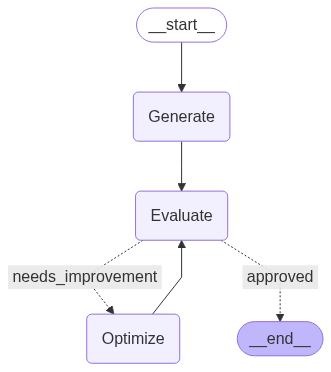

In [17]:
workflow